### 加载数据

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.qmc import LatinHypercube
from skfolio.datasets import load_sp500_dataset
from skfolio.preprocessing import prices_to_returns
from sklearn.model_selection import train_test_split
from ml4t.data.providers.qmt_provider import QmtProvider
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
# 加载数据
prices = pl.read_parquet("hs_funds_prices.parquet").to_pandas()
prices = prices.set_index('timestamp')
prices = prices.ffill()
prices = prices[prices.index.year > 2015]
all_symbols = prices.columns
print(f"资产池: {len(all_symbols)} 只 | {len(prices)} 天 | {prices.index[0].date()} ~ {prices.index[-1].date()}")

# 市场基准（从资产池中取出）
bench_symbol = "510300.SH"
bench = prices[bench_symbol]
prices = prices.drop(columns=[bench_symbol])

# 双口径收益率: X=绝对收益, X_net=超额收益(减基准), 筛选与训练统一用X_net
X = prices_to_returns(prices, drop_inceptions_nan=False)
bench_ret = prices_to_returns(bench.to_frame("bench"), drop_inceptions_nan=False)["bench"]
X_net = X.sub(bench_ret, axis=0)

# Inf 检查（两口径分别报告）
for label, df in [("X", X), ("X_net", X_net)]:
    inf = df.columns[np.isinf(df).any(axis=0)]
    print(f"{label} Inf列 {len(inf)}" + (f" -> {inf.tolist()}" if len(inf) else ""))

# 异常收益检查: 以超额口径判定, 同步剔除, 保证两口径列集一致
bad = X_net.columns[(X_net.abs() > 0.25).any()]
X = X.drop(columns=bad)
X_net = X_net.drop(columns=bad)
msg = f"异常剔除(±25%): {len(bad)} 列 -> {bad.tolist()}" if len(bad) else "异常剔除(±25%): 0 列"
print(msg)
print(f"清洗后: {X.shape[0]} 天 x {X.shape[1]} 资产 | 列集一致: {list(X.columns) == list(X_net.columns)}")

资产池: 2116 只 | 2579 天 | 2016-01-04 ~ 2026-08-14
X Inf列 0
X_net Inf列 0
异常剔除(±25%): 3 列 -> ['161811.SZ', '510030.SH', '511580.SH']
清洗后: 2578 天 x 2112 资产 | 列集一致: True


### 预筛选
对初始资产宇宙进行预选择处理，其核心目的是在构建投资组合之前，通过特定的规则筛选出符合条件的资产，从而优化后续的计算效率和模型表现。

In [3]:
from Pre_selection import DropTailCorrelated
from skfolio.pre_selection import SelectKExtremes
from skfolio.pre_selection import DropZeroVariance, DropCorrelated
from skfolio.pre_selection import SelectComplete, SelectNonExpiring, SelectNonDominated
from skfolio import RiskMeasure,PerfMeasure,RatioMeasure
from sklearn.pipeline import Pipeline

In [ ]:
selection_pipe = Pipeline([
        ("complete", SelectComplete(drop_assets_with_internal_nan=False)),
        ("variance", DropZeroVariance(threshold=1e-8)),
        ("nondomin", SelectNonDominated(min_n_assets=20, threshold=-0.35,
                        fitness_measures=[PerfMeasure.MEAN, 
                        RatioMeasure.SHARPE_RATIO, 
                        RiskMeasure.AVERAGE_DRAWDOWN])),
        ("correlate", DropCorrelated(threshold=0.1, absolute=False)),
    ])

### WalkForward+CombinatorialPurgedCV
组合净化交叉验证生成多个测试路径，以进行更稳健的时间序列模型评估和分布分析。

In [4]:
from skfolio import Population,MultiPeriodPortfolio
from skfolio import RiskMeasure,PerfMeasure,RatioMeasure,ExtraRiskMeasure
from skfolio.metrics import make_scorer
from skfolio.optimization import EqualWeighted
from skfolio.model_selection import WalkForward
from skfolio.model_selection import CombinatorialPurgedCV, cross_val_predict

In [5]:

def discrete_lhs_safe(nested_lists, n_samples, seed=None):
    """
    离散LHS采样 - 基于scipy实现，不要求元素可比较
    
    Parameters:
        nested_lists: List[List[Any]], 各子列表长度可不等
        n_samples: int, 采样数量
        seed: int | None, 随机种子
    Returns:
        List[Tuple[Any, ...]]
    """
    n_factors = len(nested_lists)
    n_levels = np.array([len(lst) for lst in nested_lists])  # 支持各维度层级数不同

    # ① 连续空间 LHS（scipy 内部用优化算法，比手写 permutation 更均匀）
    sampler = LatinHypercube(d=n_factors, seed=seed)
    unit_samples = sampler.random(n=n_samples)  # (n_samples, n_factors) ∈ [0,1)

    # ② 向量化映射到离散层级索引（一行替代循环）
    level_indices = np.clip(
        (unit_samples * n_levels[np.newaxis, :]).astype(np.intp),
        0,
        n_levels[np.newaxis, :] - 1
    )  # (n_samples, n_factors)

    # ③ 构建 object 查找表 + 高级索引一次性取值
    # ③ 构建 object 查找表（逐元素赋值，避免触发 __array__ 协议）
    max_levels = int(n_levels.max())
    lookup = np.empty((n_factors, max_levels), dtype=object)
    for j, lst in enumerate(nested_lists):
        for k, obj in enumerate(lst):
            lookup[j, k] = obj          # ← 单个 object 赋值，安全

    col_idx = np.arange(n_factors)[np.newaxis, :]
    samples_array = lookup[col_idx, level_indices]

    return [tuple(row) for row in samples_array]

### 方案B: 嵌套自适应参数搜索（WF 外层 × CPCV 内层搜索）

与全局搜索的本质区别（解决 WalkForward 均值选参过拟合）:
- 外层 WalkForward 切分 train_i / test_i, **test_i 绝不进入任何搜索**（纯净 OOS）
- 每个外层折在内层 train_i 上做 CPCV 参数搜索, 选出**该折最优参数**（策略随市场状态自适应: 好时候放大正相关, 震荡期注重负相关, 而不是一个固定阈值横跨多年）
- 用该折参数在纯净 test_i 上预测 → 收集全部 test 段
- test 段重组（block bootstrap）→ 路径分布, 观察自适应流程的长期表现与上下限
- **train_size 也进入内层搜索**: 每折可自适应选择训练子窗口长度;
- 内层 CPCV 输入 = 该折训练子窗口 ts 天 + test_size 天测试段(与外层 test 同长), 与 WF 结构一致
- ts 上限约束: ts ≤ 外层train_size - test_size, 保证内层窗口不超出外层训练段


In [12]:
# ===== 方案B核心: 嵌套自适应参数搜索 (Optuna) =====
# 结构: 外层WF(train/test严格隔离) -> 每折内层CPCV + Optuna搜参 -> 该折参数预测纯净test段
import optuna
# 完全关闭日志
optuna.logging.set_verbosity(optuna.logging.WARNING)

class StopWhenNoImprovement:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience = patience        # 连续多少次无提升就停止
        self.min_delta = min_delta      # 提升多少才算"有效改善"
        self.best_value = None
        self.no_improve_count = 0

    def __call__(self, study, trial):
        current_value = study.best_value
        
        if self.best_value is None:
            self.best_value = current_value
            return
        
        # 判断是否有有效改善
        if current_value - self.best_value > self.min_delta:
            self.best_value = current_value
            self.no_improve_count = 0
        else:
            self.no_improve_count += 1
        
        if self.no_improve_count >= self.patience:
            print(f"\n连续 {self.patience} 次 trial 无有效改善，提前停止。")
            study.stop()

def build_model(params):
    """由参数字典构造 筛选+等权 pipeline（train_size 不在此处, 由训练子窗口控制）"""
    return Pipeline([
        ("complete", SelectComplete(drop_assets_with_internal_nan=False)),
        ("variance", DropZeroVariance(threshold=1e-8)),
        ("nondomin", SelectNonDominated(
            min_n_assets=params["min_n_assets"],
            threshold=params["threshold"],
            fitness_measures=params["fitness_measures"],
        )),
        ("correlate", DropCorrelated(threshold=params["corr_threshold"])),
        ("optimization", EqualWeighted()),
    ])

def inner_cpcv_score(X_tr, params, test_size, n_jobs=4, n_test_folds=2):
    """在 train+test 合并窗口上做 CPCV, 返回路径年化的中位数
    窗口 = 内层训练 ts 天 + 内层测试 test_size 天(与外层 test 同长)
    块长 = test_size // n_test_folds, n_folds = 窗口天数 // 块长
    -> 最后 n_test_folds 块恰好覆盖 test_size 天, 前 n_folds-n_test_folds 块覆盖 ts 天"""
    model = build_model(params)
    block = max(1, test_size // n_test_folds)
    n_folds = max(n_test_folds + 1, len(X_tr) // block)
    inner_cv = CombinatorialPurgedCV(n_folds=n_folds, n_test_folds=n_test_folds, purged_size=2, embargo_size=2)
    cvp = cross_val_predict(model, X_tr, cv=inner_cv, n_jobs=n_jobs)
    ann_mean = np.array([mptf.annualized_mean for mptf in cvp])
    max_dd = np.array([mptf.max_drawdown for mptf in cvp])
    skew = np.array([mptf.skew for mptf in cvp])
    return float(np.mean(ann_mean) - np.mean(max_dd) + np.mean(skew))

def search_inner_params(X_tr, param_grid, test_size, n_test_folds=2, n_jobs=4, n_trials=40, verbose=True):
    """Optuna搜索: 在 train_i 上用 TPE 优化 CPCV 路径年化中位数, 返回该折最优参数
    inner_cv 不在外部传递: 每次 trial 由 inner_cpcv_score 按子窗口长度动态构建"""
    fm_choices = param_grid["fitness_measures"]     # dict: 名称 -> 度量组合
    t_lo, t_hi = param_grid["threshold_range"]
    c_lo, c_hi = param_grid["corr_range"]
    m_lo, m_hi, m_step = param_grid["min_n_assets"]
    w_lo, w_hi, w_step = param_grid["train_size"]   # 训练子窗口 (start, stop, step)

    def objective(trial):
        # 无序分类参数: fitness_measures 是筛选逻辑, 让 TPE 按类别采样
        fm_name = trial.suggest_categorical("fitness_measures", list(fm_choices))
        params = {
            "threshold": trial.suggest_float("threshold", t_lo, t_hi, step=0.1),
            "min_n_assets": trial.suggest_int("min_n_assets", m_lo, m_hi, step=m_step),
            "fitness_measures": fm_choices[fm_name],
            "corr_threshold": trial.suggest_float("corr_threshold", c_lo, c_hi, step=0.1),
            # 有序参数: train_size 是数值天数, 让 TPE 感知数值距离
            "train_size": trial.suggest_int("train_size", w_lo, w_hi, step=w_step),
        }
        ts = params["train_size"]
        # 内层 CPCV 输入 = 训练 ts 天 + 测试 test_size 天(与外层 WF 结构一致);
        # ts 上限受约束(≤ 外层train-test_size), 保证 ts+test_size 不超出 X_tr
        w = X_tr.iloc[-(ts + test_size):]
        return inner_cpcv_score(w, params, test_size, n_jobs=n_jobs, n_test_folds=n_test_folds)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(objective, 
                   n_trials=n_trials, 
                   show_progress_bar=verbose,
                   callbacks=[StopWhenNoImprovement(patience=50, min_delta=1e-4)])
    best = dict(study.best_params)
    best["fitness_measures"] = fm_choices[best.pop("fitness_measures")]  # 名称 -> 度量组合
    if verbose:
        print(f"    best: {best} -> median={study.best_value:.4f}")
    return best, study.best_value

def nested_adaptive_search(X, test_size=126, train_size=756, param_grid=None,
                           n_test_folds=2, n_jobs=4, n_trials=40, verbose=True):
    """方案B主循环: 外层WF滚动, 每折内层Optuna独立搜参, 该折参数预测纯净test段
    inner_cv 不再由外部传入: 每折搜索内部按训练子窗口动态构建"""
    if param_grid is None:
        param_grid = {
            "threshold_range": (-0.6, -0.5),        # 依据252*2窗口实测的配对分布收敛区间
            "min_n_assets": (15, 25, 5),
            "fitness_measures": {
                "mean-sharpe-ratio-avgdd": [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.AVERAGE_DRAWDOWN],
                "mean-sortino-ratio-cvar": [PerfMeasure.MEAN, RatioMeasure.SORTINO_RATIO, RiskMeasure.CVAR],
                "mean-variance-cvar": [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.CVAR],
            },
            "corr_range": (0.1, 0.2),
            "train_size": (252, 504, 126),           # 训练子窗口1~2年(CPCV输入另含 test_size 天测试段; 上限≤外层train-test_size)
        }
    outer_cv = WalkForward(test_size=test_size, train_size=train_size,
                           purged_size=1, reduce_test=True, expand_train=False)
    folds = []
    for i, (tr_idx, te_idx) in enumerate(outer_cv.split(X)):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        if len(X_tr) < 252:
            continue
        # 1) 内层搜索（只触碰训练块, test段保持纯净）
        best, score = search_inner_params(X_tr, param_grid, test_size,
                                          n_test_folds=n_test_folds,
                                          n_jobs=n_jobs, n_trials=n_trials, verbose=verbose)
        # 2) 用该折最优参数重建模型, fit在训练子窗口, 直接predict纯净test段
        #    (Pipeline已含EqualWeighted最后一步, predict内部完成筛选+优化)
        w = X_tr.iloc[-best["train_size"]:]
        m = build_model(best)
        m.fit(w)
        test_ptf = m.predict(X_te)
        test_ptf.name = f"Fold{i}"   # predict 不接受 portfolio_params(0.20.x), 预测后设置名称
        folds.append({"fold": i, "params": best, "inner_median": score, "test": test_ptf})
        print(f"Fold {i}: best={best} | inner_median={score:.4f} | test_ann={test_ptf.annualized_mean:.4f} | test_days={len(test_ptf.returns)}")
    return folds

In [11]:
# Perf + Risk + Ratio
FITNESS_MEASURES = {
    "mean-sortino-ratio-cvar":            [PerfMeasure.MEAN, RatioMeasure.SORTINO_RATIO, RiskMeasure.CVAR],
    "mean-sharpe-ratio-avgdd":            [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.AVERAGE_DRAWDOWN],
    "mean-sharpe-ratio-avgdd-kurt":       [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.AVERAGE_DRAWDOWN, ExtraRiskMeasure.KURTOSIS],
    "mean-sharpe-ratio-cdar":             [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.CDAR],
    "mean-sharpe-ratio-cvar":             [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.CVAR],
    "mean-sharpe-ratio-ulcer":            [PerfMeasure.MEAN, RatioMeasure.SHARPE_RATIO, RiskMeasure.ULCER_INDEX],
    "mean-variance-cvar":                 [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.CVAR],
    "mean-variance-kurt":                 [PerfMeasure.MEAN, RiskMeasure.VARIANCE, ExtraRiskMeasure.KURTOSIS],
    "mean-semivariance-cvar":             [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.CVAR],
    "mean-variance-avgdd":                [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
    "mean-semivariance-avgdd":            [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],

}

In [10]:
FITNESS_MEASURES = {
    "mean-variance-avgdd":                [PerfMeasure.MEAN, RiskMeasure.VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
    "mean-semivariance-avgdd":            [PerfMeasure.MEAN, RiskMeasure.SEMI_VARIANCE, RiskMeasure.AVERAGE_DRAWDOWN],
}

In [ ]:
# ===== 运行嵌套自适应搜索 (Optuna) =====
# test_size 固定 126 天(半季), 外层 train_size 固定 756 天(3年), 内层 train_size 自适应
# 每折内层 Optuna: TPE采样, objective = CPCV路径年化中位数（非均值）
# 计算量: 约15折 x 40 trials x CPCV(28内层fold), 建议 n_jobs=8, 预计耗时较长
param_grid = {
            "threshold_range": (-0.5, -0.4),        # 依据252*2窗口实测的配对分布收敛区间
            "min_n_assets": (5, 15, 5),
            "fitness_measures": FITNESS_MEASURES,
            "corr_range": (0.1, 0.3),
            "train_size": (252, 504, 126),           #inner train_size最大不能超过outer train_size - test_size
        }
folds = nested_adaptive_search(X, 
                               test_size=126, 
                               train_size=int(252*2.5), 
                               n_test_folds=2, n_jobs=12, n_trials=100, 
                               param_grid=param_grid, verbose=True)

In [14]:
(252*3 - 63)/126

5.5

In [16]:
# ===== 每折参数驱动的 WF×CPCV 多路径压测 (真多路径) =====
# 外层WF按最长 train+test 分折(test连续, 训练取最新), 每折用方案B搜出的参数 p_i
# 构造模型 -> (train_i+test_i)合并窗口内 CPCV -> 每个test样本被7条路径各预测一次
# p_i 只见过 train_i(test_i 纯净), 参数冻结 -> 压测路径为真 OOS 多路径
# train_size 参与压测: 窗口 = train_i最近train_size天 + test_i, 与搜索时模型fit口径一致

def adaptive_multi_paths(X, folds, test_size=126, train_size=756,
                         n_test_folds=2, n_jobs=4, verbose=True):
    """每折: 参数p_i + (train_i最近train_size天 + test_i)窗口内CPCV
    -> {fold: {path_id: [test块1, test块2, ...]}}; 窗口按该折train_size截断
    test两折为独立段(独立组合单元), 不拼成MPTF"""
    outer_cv = WalkForward(test_size=test_size, train_size=train_size,
                           purged_size=1, reduce_test=False, expand_train=False)
    params_by_fold = {f["fold"]: f["params"] for f in folds}
    fold_paths = {}
    for i, (tr_idx, te_idx) in enumerate(outer_cv.split(X)):
        if i not in params_by_fold:
            continue
        p = params_by_fold[i]
        # 窗口 = train_i 最近 train_size 天 + test_i (搜索时模型fit口径)
        ts = p["train_size"]                            # N=最近N天
        ts_len = ts
        w_idx = np.concatenate([tr_idx[-ts_len:], te_idx])
        window = X.iloc[w_idx]
        # 内层CPCV: 块长=test_size//n_test_folds, n_folds=窗口天数//块长
        # 使最后 n_test_folds 块恰好覆盖 test_size 天, 与内层搜索口径一致
        inner_cv = CombinatorialPurgedCV(n_folds=len(window) // (test_size // n_test_folds),
                                         n_test_folds=n_test_folds,
                                         purged_size=2, embargo_size=2)
        model = build_model(p)
        cvp = cross_val_predict(model, window, cv=inner_cv,
                                n_jobs=n_jobs, portfolio_params=dict(name=f"F{i}"))
        # test 段 = 每条路径最后 n_test_folds 个独立块(段), 不拼接, 作为独立组合单元
        fold_paths[i] = {pid: mptf[-n_test_folds:] for pid, mptf in enumerate(cvp)}
        if verbose:
            print(f"Fold {i}: paths={len(cvp)} | window={len(window)} | "
                  f"inner_folds={inner_cv.n_folds} | test_days={len(te_idx)}")
    return fold_paths

Fold 0: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 1: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 2: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 3: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 4: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 5: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 6: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 7: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 8: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 9: paths=9 | window=630 | inner_folds=10 | test_days=126
Fold 10: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 11: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 12: paths=5 | window=378 | inner_folds=6 | test_days=126
Fold 13: paths=7 | window=504 | inner_folds=8 | test_days=126
Fold 14: paths=9 | window=630 | inner_folds=10 | test_days=126
LHS多路径分布(1000条): 均值 0.0709 | 中位 0.0709 | 5% 0.0529 | 95% 0.0875
WF真实路径: 0.08

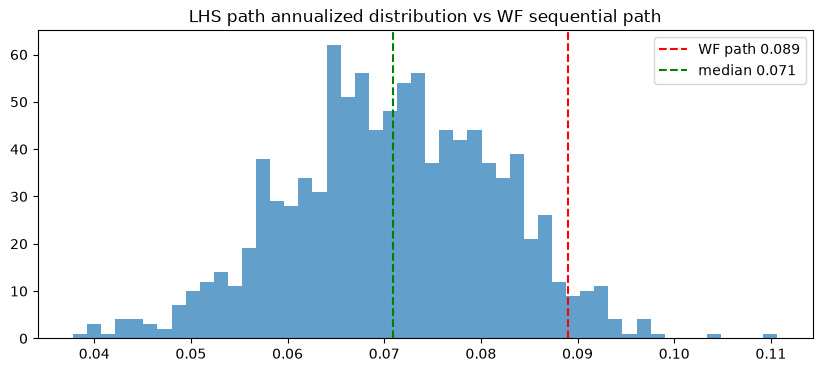

In [17]:

fold_paths = adaptive_multi_paths(X, folds, test_size=126, train_size=int(252*2.5),
                                  n_test_folds=2, n_jobs=8)   # 与搜索cell12一致

# ---- 跨折LHS组合: test两折独立段, 每折2个段单元(路径数随折可变: 5或7) -> 完整OOS路径分布 ----
folds_list = sorted(fold_paths.keys())
n_blocks = len(fold_paths[0][0])                      # 每路径test段块数(2)
all_test_parts = []                                   # 段单元: (折, 块), 共 len(folds_list)*2 个
for i in folds_list:
    for b in range(n_blocks):
        all_test_parts.append([fold_paths[i][pid][b] for pid in sorted(fold_paths[i])])
# 超立方采样，每条=段单元数个Portfolio元组
samples = discrete_lhs_safe(all_test_parts, n_samples=1000, seed=42)   

# 路径图: 1000条组合路径累计收益
#Population([MultiPeriodPortfolio(sample, compounded=False) for sample in samples]).plot_cumulative_returns()

# 年化分布
path_anns = np.array([MultiPeriodPortfolio(sample).annualized_mean for sample in samples])

wf_ann = MultiPeriodPortfolio([f["test"] for f in folds[:]]).annualized_mean

print(f"LHS多路径分布({len(path_anns)}条): 均值 {path_anns.mean():.4f} | 中位 {np.median(path_anns):.4f} | "
      f"5% {np.percentile(path_anns,5):.4f} | 95% {np.percentile(path_anns,95):.4f}")
print(f"WF真实路径: {wf_ann:.4f} | 分布中 {(wf_ann-path_anns.mean())/path_anns.std():.2f}σ | "
      f"分位 {(path_anns < wf_ann).mean():.1%}")

plt.figure(figsize=(10,4))
plt.hist(path_anns, bins=50, alpha=0.7)
plt.axvline(x=wf_ann, c='red', ls='--', label=f'WF path {wf_ann:.3f}')
plt.axvline(x=np.median(path_anns), c='green', ls='--', label=f'median {np.median(path_anns):.3f}')
plt.legend(); plt.title('LHS path annualized distribution vs WF sequential path'); plt.show()


LHS多路径分布(1000条): 均值 0.5316 | 中位 0.5320 | 5% 0.3967 | 95% 0.6562
WF真实路径: 0.6880 | 分布中 1.92σ | 分位 97.7%


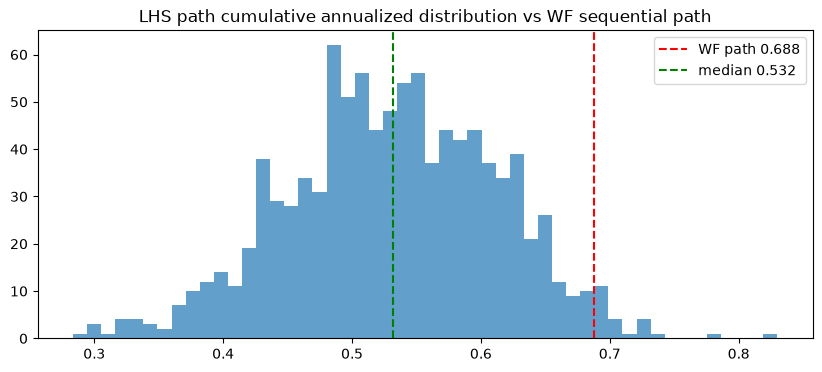

In [18]:
# 年化分布
path_anns = np.array([MultiPeriodPortfolio(sample).cumulative_returns[-1] for sample in samples])

wf_ann = MultiPeriodPortfolio([f["test"] for f in folds[:]]).cumulative_returns[-1]

print(f"LHS多路径分布({len(path_anns)}条): 均值 {path_anns.mean():.4f} | 中位 {np.median(path_anns):.4f} | "
      f"5% {np.percentile(path_anns,5):.4f} | 95% {np.percentile(path_anns,95):.4f}")
print(f"WF真实路径: {wf_ann:.4f} | 分布中 {(wf_ann-path_anns.mean())/path_anns.std():.2f}σ | "
      f"分位 {(path_anns < wf_ann).mean():.1%}")

plt.figure(figsize=(10,4))
plt.hist(path_anns, bins=50, alpha=0.7)
plt.axvline(x=wf_ann, c='red', ls='--', label=f'WF path {wf_ann:.3f}')
plt.axvline(x=np.median(path_anns), c='green', ls='--', label=f'median {np.median(path_anns):.3f}')
plt.legend(); plt.title('LHS path cumulative annualized distribution vs WF sequential path'); plt.show()


In [19]:
MultiPeriodPortfolio([f["test"] for f in folds[:]]).plot_cumulative_returns()

In [ ]:
Population([MultiPeriodPortfolio(sample, compounded=False) for sample in samples]).plot_cumulative_returns()

In [100]:
# ===== 每折自适应参数一览 =====
rows = []
for f in folds:
    p = dict(f["params"])
    p["fitness"] = str(p["fitness_measures"])
    del p["fitness_measures"]
    rows.append({"fold": f["fold"], "inner_median": round(f["inner_median"], 4), **p})
print(pd.DataFrame(rows).to_string(index=False))

 fold  inner_median  threshold  min_n_assets  corr_threshold  train_size                                          fitness
    0        0.0283      -0.45            10             0.2         630                       [Mean, Sharpe Ratio, CDaR]
    1        0.0622      -0.50            10             0.2         252                       [Mean, Variance, Kurtosis]
    2        0.1271      -0.45            10             0.3         252 [Mean, Sharpe Ratio, Average Drawdown, Kurtosis]
    3        0.1641      -0.50            10             0.3         252 [Mean, Sharpe Ratio, Average Drawdown, Kurtosis]
    4        0.1386      -0.45            10             0.3         378                       [Mean, Sharpe Ratio, CDaR]
    5        0.1844      -0.50            10             0.3         504                       [Mean, Sharpe Ratio, CDaR]
    6        0.1141      -0.40            10             0.3         630 [Mean, Sharpe Ratio, Average Drawdown, Kurtosis]
    7        0.0809     

In [21]:
# ===== 每折自适应参数一览 =====
rows = []
for f in folds:
    p = dict(f["params"])
    p["fitness"] = str(p["fitness_measures"])
    del p["fitness_measures"]
    rows.append({"fold": f["fold"], "inner_median": round(f["inner_median"], 4), **p})
print(pd.DataFrame(rows).to_string(index=False))

 fold  inner_median  threshold  min_n_assets  corr_threshold  train_size                                 fitness
    0       -0.0188       -0.5             5             0.1         504      [Mean, Variance, Average Drawdown]
    1       -0.0134       -0.5            10             0.1         378 [Mean, Semi-Variance, Average Drawdown]
    2        0.3270       -0.5             5             0.1         252 [Mean, Semi-Variance, Average Drawdown]
    3        0.1824       -0.4            15             0.1         504      [Mean, Variance, Average Drawdown]
    4        0.3260       -0.5            10             0.2         252 [Mean, Semi-Variance, Average Drawdown]
    5        0.2335       -0.4            10             0.2         378 [Mean, Semi-Variance, Average Drawdown]
    6        0.0668       -0.5             5             0.1         378      [Mean, Variance, Average Drawdown]
    7        0.4074       -0.5            10             0.1         378 [Mean, Semi-Variance, A

In [22]:
MultiPeriodPortfolio([f["test"] for f in folds[:]]).summary()

Mean                                     0.035%
Annualized Mean                           8.90%
Variance                                0.0021%
Annualized Variance                       0.52%
Semi-Variance                           0.0011%
Annualized Semi-Variance                  0.27%
Standard Deviation                        0.45%
Annualized Standard Deviation             7.21%
Semi-Deviation                            0.32%
Annualized Semi-Deviation                 5.16%
Mean Absolute Deviation                   0.25%
CVaR at 95%                               1.04%
EVaR at 95%                               3.31%
Worst Realization                         6.71%
CDaR at 95%                               4.74%
MAX Drawdown                             10.32%
Average Drawdown                          0.98%
EDaR at 95%                               6.52%
First Lower Partial Moment                0.13%
Ulcer Index                               0.015
Gini Mean Difference                    

 CPCV 路径结果计算 PBO 和 Deflated Sharpe Ratio (DSR) 的核心代码

In [46]:
import numpy as np
from scipy.stats import skew, kurtosis, norm
from scipy.integrate import quad


def diagnose_oos_lhs(fold_paths, n_test_folds, n_samples=10000, annual_factor=252,
                     risk_free_rate=0.02, n_trials=1, seed=42):
    """
    纯 OOS 策略诊断 (LHS + MultiPeriodPortfolio)
    
    Parameters:
        fold_paths: dict, {wf_idx: {pid: [Portfolio_block0, Portfolio_block1, ...]}}
        n_test_folds: int, 每条路径的 test 段块数（即 all_test_parts 中每折展开的维度数）
        n_samples: int, LHS 采样路径数
        annual_factor: int, 年化交易日
        risk_free_rate: float, 无风险利率
        n_trials: int, DSR 的独立试验数 N（整个流程被独立评估并挑选最优的次数）;
        纯 OOS 单流程无跨数据集挑选 -> 取 1
        seed: int | None, 随机种子
    """
    # ==========================================================
    # 1. 按 (折, 块) 构建 LHS 输入
    # ==========================================================
    folds_list = sorted(fold_paths.keys())
    n_blocks = n_test_folds

    all_test_parts = []
    for i in folds_list:
        pids_sorted = sorted(fold_paths[i])
        for b in range(n_blocks):
            all_test_parts.append([fold_paths[i][pid][b] for pid in pids_sorted])

    total_dims = len(all_test_parts)
    T_total = sum(len(np.asarray(part[0].returns)) for part in all_test_parts)

    print(f"[Info] {len(folds_list)} WF × {n_blocks} blocks = {total_dims} LHS dims | OOS {T_total} days")

    # ==========================================================
    # 2. LHS → MultiPeriodPortfolio → returns matrix
    # ==========================================================
    samples = discrete_lhs_safe(all_test_parts, n_samples=n_samples, seed=seed)

    full_paths = np.empty((n_samples, T_total))
    for i, sample_tuple in enumerate(samples):
        mpp = MultiPeriodPortfolio(sample_tuple)
        rets = np.asarray(mpp.returns, dtype=float)
        full_paths[i] = np.nan_to_num(rets, nan=0.0)

    # ==========================================================
    # 3. Sharpe & MDD
    # ==========================================================
    excess = full_paths - (risk_free_rate / annual_factor)
    means = excess.mean(axis=1)
    stds = full_paths.std(axis=1, ddof=1)
    stds = np.where(stds < 1e-12, 1e-12, stds)
    oos_sharpes = (means / stds) * np.sqrt(annual_factor)

    cum_ret = np.cumprod(1 + full_paths, axis=1)
    running_max = np.maximum.accumulate(cum_ret, axis=1)
    mc_mdds = np.min((cum_ret - running_max) / running_max, axis=1)

    # ==========================================================
    # 4. DSR
    # ==========================================================
    canon_tuple = tuple(part[0] for part in all_test_parts)
    canon_rets = np.nan_to_num(
        np.asarray(MultiPeriodPortfolio(canon_tuple).returns, dtype=float), nan=0.0
    )
    # DSR 偏度/峰度与 Sharpe 同口径: 使用超额收益
    canon_excess = canon_rets - (risk_free_rate / annual_factor)
    gamma3 = skew(canon_excess)
    gamma4 = kurtosis(canon_excess) + 3

    sr_obs = np.median(oos_sharpes)

    # e_max = E[max_N Z]: N 个独立标准正态最大值的期望, 数值积分对任意 N 精确;
    # Bailey & López de Prado(2014) 渐近式仅对大 N 有效, N 小时失真
    def expected_max_std_normal(n):
        if n <= 1:
            return 0.0
        def integrand(z):
            return z * norm.pdf(z) * norm.cdf(z) ** (n - 1)
        val, _ = quad(integrand, -8.0, 8.0, limit=400)
        return n * val

    e_max = expected_max_std_normal(n_trials)
    # Lo(2002) Sharpe 方差项: 系数 (γ4-1)/4 (原代码误写 /24)
    inflation = max(1 - gamma3 * sr_obs + (gamma4 - 1) * sr_obs ** 2 / 4, 1e-8)
    # z = t(SR_obs) - e_max: e_max 为标准化 z 单位, 不能再乘 sqrt(T-1)
    z_score = np.sqrt(max(T_total - 1, 1)) * sr_obs / np.sqrt(inflation) - e_max
    dsr = norm.cdf(z_score)
    prob_loss = np.mean(oos_sharpes <= 0)

    # ==========================================================
    # 5. Report
    # ==========================================================
    print("\n" + "=" * 60)
    print("          纯 OOS 策略诊断报告 (LHS)")
    print("=" * 60)
    print(f"  ✅ P(SR<=0)              : {prob_loss:.2%}")
    print(f"  ✅ Sharpe 90% CI         : [{np.percentile(oos_sharpes, 5):.3f}, "
          f"{np.percentile(oos_sharpes, 95):.3f}]")
    print(f"  ✅ MDD median / 5%-tile  : {np.median(mc_mdds):.2%} / "
          f"{np.percentile(mc_mdds, 5):.2%}")
    print("-" * 60)
    print(f"  ⚠️ SR_obs (median)       : {sr_obs:.4f}")
    print(f"  ⚠️ DSR                   : {dsr:.4f}  (z={z_score:.2f}, n_trials={n_trials})")
    print("=" * 60)

    return {
        "prob_loss": prob_loss, "dsr": dsr, "sr_obs": sr_obs,
        "e_max": e_max, "z_score": z_score,
        "mc_sharpes": oos_sharpes, "mc_mdds": mc_mdds,
        "T_total": T_total, "n_trials": n_trials
    }

In [49]:
# fold_paths: {wf_idx: {pid: [Portfolio_b0, Portfolio_b1]}}
# discrete_lhs_safe, MultiPeriodPortfolio 需已在作用域中定义

res = diagnose_oos_lhs(
    fold_paths=fold_paths,
    n_test_folds=2,        # ← 每条路径的 test 块数，直接传入
    n_samples=10000,
    annual_factor=252,
    risk_free_rate=0.02,
    n_trials=1,              # 独立试验数 N: 方案B单流程无跨数据集挑选 -> 1
    seed=42
)

# 返回值使用
print(f"OOS 亏损概率: {res['prob_loss']:.2%}")
print(f"DSR: {res['dsr']:.4f}")
sharpes = res["mc_sharpes"]  # shape: (n_samples,)
mdds = res["mc_mdds"]        # shape: (n_samples,)

[Info] 15 WF × 2 blocks = 30 LHS dims | OOS 1890 days

          纯 OOS 策略诊断报告 (LHS)
  ✅ P(SR<=0)              : 0.00%
  ✅ Sharpe 90% CI         : [0.449, 0.909]
  ✅ MDD median / 5%-tile  : -9.24% / -11.17%
------------------------------------------------------------
  ⚠️ SR_obs (median)       : 0.6815
  ⚠️ DSR                   : 1.0000  (z=17.48, n_trials=1)
OOS 亏损概率: 0.00%
DSR: 1.0000


参数敏感性分析

In [50]:
rows = []
for f in folds:
    rows.append({"fold": f["fold"],
                 "threshold": f["params"]["threshold"],
                 "corr": f["params"]["corr_threshold"],
                 "train_size": f["params"]["train_size"],
                 "test_ann": f["test"].annualized_mean})
df = pd.DataFrame(rows)
# 看: threshold 取值分布是否散布在 [-0.5,-0.4] 内、与 test_ann 是否单调/相关

In [51]:
df

,fold,threshold,corr,train_size,test_ann
0,0,-0.5,0.1,504,0.026078
1,1,-0.5,0.1,378,0.133452
2,2,-0.5,0.1,252,0.202879
3,3,-0.4,0.1,504,0.142521
4,4,-0.5,0.2,252,0.059342
5,5,-0.4,0.2,378,0.107630
6,6,-0.5,0.1,378,0.014148
7,7,-0.5,0.1,378,0.023204
8,8,-0.5,0.1,378,0.033023
9,9,-0.5,0.1,504,0.082458
